IMdB rating of each per kill count 

In [176]:
#loaidng both csv files.
imdb_df = pd.read_csv('Quentin_Tarantino_IMDB_Cleaned_Updated.csv')

kill_count_df = pd.read_csv('split_movie_title_year.csv')

#merging through 'title'
mix_df = pd.merge(imdb_df, kill_count_df, left_on='Title', right_on='title', how='outer')  
mix_df.head(2)

,IMDb Ranking,Title,Duration (Minutes),Rating,Votes,Genre,Content Rating,URL,Description,Poster,kill_count,title,year
0,2,Reservoir Dogs,99,8.3,1130858,"Crime, Thriller",18,https://www.imdb.com/title/tt0105236/,When a simple jewelry heist goes horribly wron...,https://m.media-amazon.com/images/M/MV5BMmMzYj...,11,Reservoir Dogs,1992
1,3,Pulp Fiction,154,8.9,2330768,"Crime, Drama",18,https://www.imdb.com/title/tt0110912/,"The lives of two mob hitmen, a boxer, a gangst...",https://m.media-amazon.com/images/M/MV5BYTViYT...,15,Pulp Fiction,1994


In [177]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Clean and prep data
plot_df = mix_df.dropna(subset=['Rating', 'kill_count', 'Poster', 'year', 'Title']).copy()
plot_df['kill_count'] = pd.to_numeric(plot_df['kill_count'], errors='coerce')

# Create label for x-axis: "Title (Year)"
plot_df['label'] = plot_df.apply(lambda row: f"{row['Title']} ({int(row['year'])})", axis=1)

# Sort by release year
plot_df = plot_df.sort_values('year')


# Creating subplot with seocndary y-axis.
fig = make_subplots(specs=[[{"secondary_y": True}]])

#creating bar chart for kill count.
fig.add_trace(
    go.Bar(
        x=plot_df['label'],
        y=plot_df['kill_count'],
        name="Kill Count",
        marker_color='#8B0000',
    ),
    secondary_y=False
)

#creating the line graph for IMDb 
fig.add_trace(
    go.Scatter(
        x=plot_df['label'],
        y=plot_df['Rating'],
        name="IMDb Rating",
        mode='lines+markers',
        line=dict(color='black'),
        marker=dict(size=10),  
    ),
    secondary_y=True
)

#layout settings
fig.update_layout(
    title_text="Tarantino Films: Kill Count & IMDb Rating Over Time",
    xaxis_title="Movie (Year)",
    yaxis_title="Kill Count (deaths)",
    width=1100,
    height=600,
    paper_bgcolor='white',
    plot_bgcolor='white',
    showlegend=True,
    legend=dict(x=0.01, y=0.99, bgcolor='rgba(255,255,255,0.5)'),
)

#rmeoving grid lines to make it look cleaner.
fig.update_xaxes(showgrid=False, showline=True, linecolor='black', tickangle=45)
fig.update_yaxes(showgrid=False, showline=True, linecolor='black', secondary_y=False)
fig.update_yaxes(showgrid=False, showline=True, linecolor='black', secondary_y=True)

#setting IMDb range.
fig.update_yaxes(title_text="IMDb Rating", range=[0, 10], secondary_y=True)
#showing plot.
fig.show()


Character Kills vs Fate

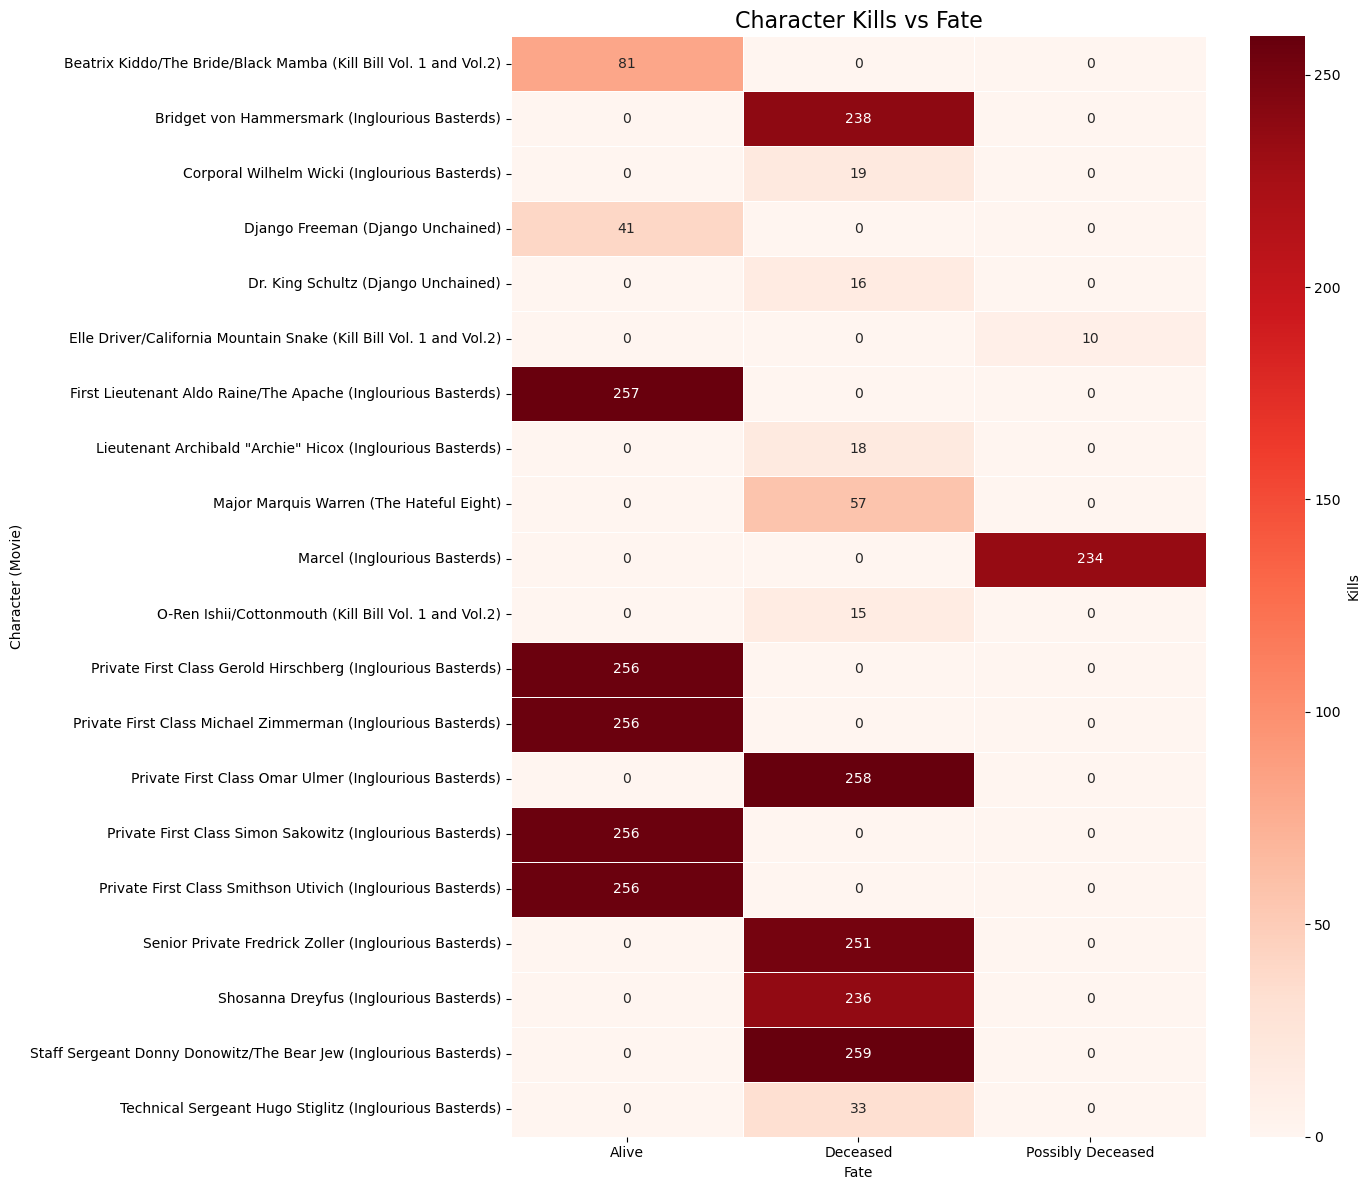

In [178]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#loading csv file
df=pd.read_csv("top_20_killers.csv")

#confriming kills are numeric
df['Kills'] = pd.to_numeric(df['Kills'], errors='coerce')

#combing character and movie title
df['Character_Label'] = df['Character'] +" (" + df['Movie'] + ")"
#creating puvot table with kills as values
pivot = df.pivot_table(index="Character_Label", columns="Fate", values="Kills", aggfunc="sum", fill_value=0)
#plotting the heat map
plt.figure(figsize= (14, 12))
sns.heatmap(pivot, cmap="Reds", annot=True, fmt='d', linewidths=0.5, cbar_kws={'label': 'Kills'})
plt.title('Character Kills vs Fate', fontsize=16)
plt.ylabel('Character (Movie)')
plt.xlabel('Fate')
plt.tight_layout()
plt.show()


Killer by gender per film

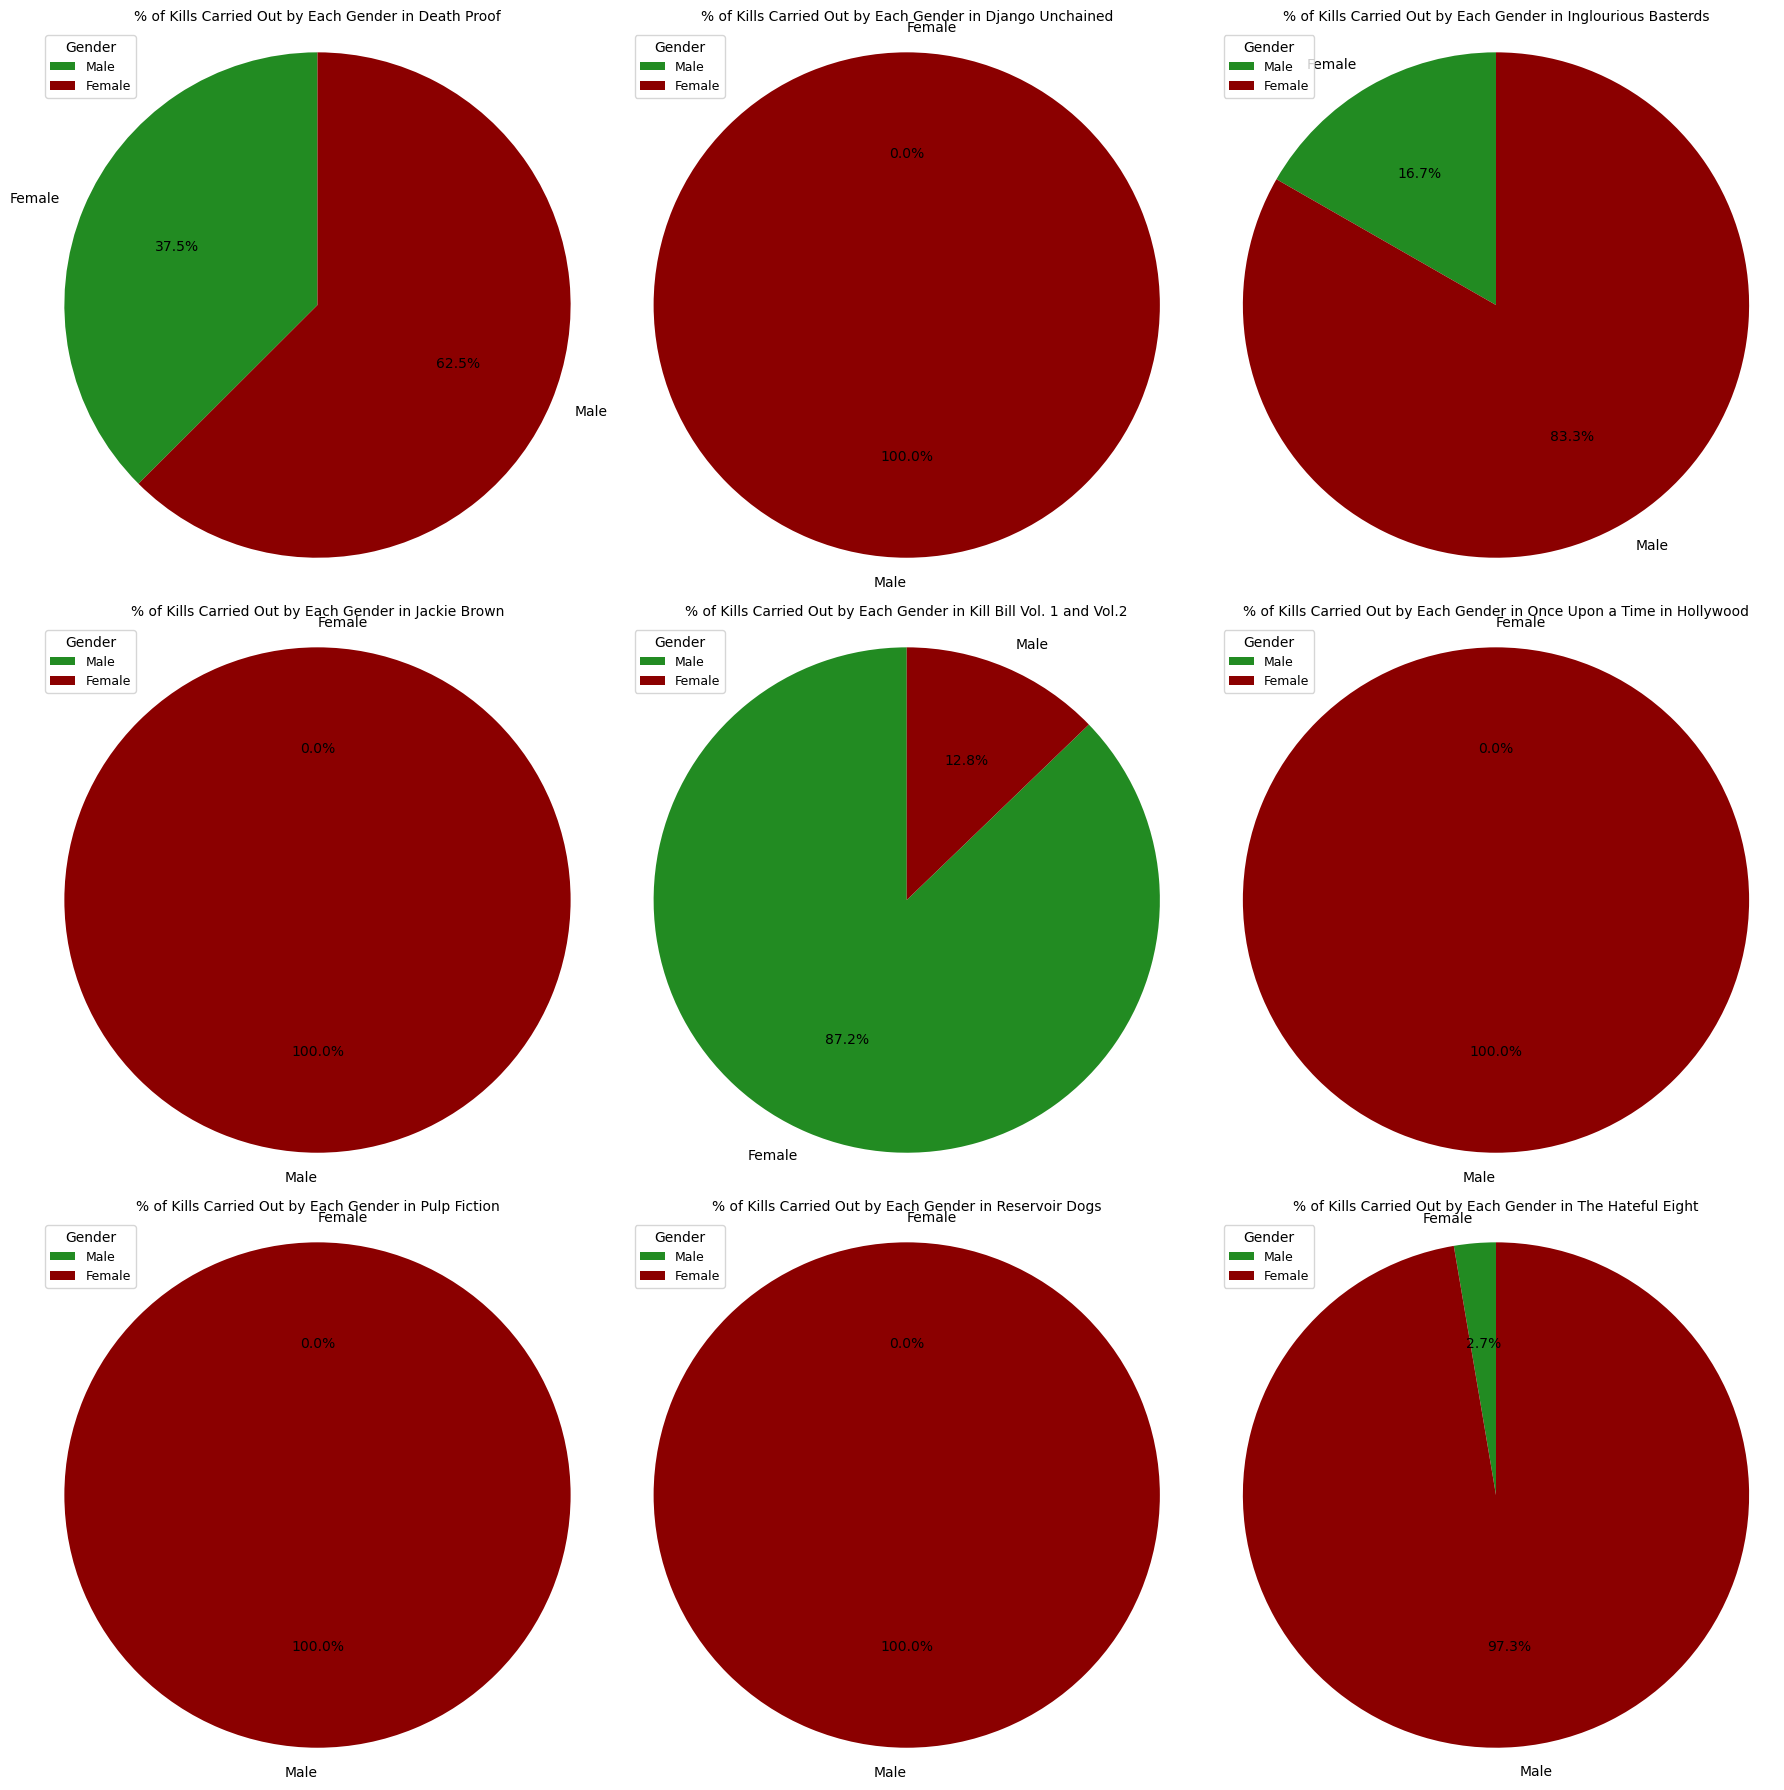

In [179]:
import pandas as pd
import matplotlib.pyplot as plt

#loading data from csv file.
df = pd.read_csv("all_killers.csv")

#confirming there are no NaN values
df =df.dropna(subset=['Kills', 'Gender'])
# grouping the data and finding the sum of kills.
gender_kills =df.groupby(['Movie', 'Gender'])['Kills'].sum().unstack(fill_value =0)

#creating the pie charts for each movie.
movies= gender_kills.index

#making sure there are the correct number of rows for the presentation of each chart
num_movies = len(movies)
num_rows= 3
num_cols=(num_movies + num_rows - 1) // num_rows 

#setting up axis.
fig, axes= plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(num_cols * 6, num_rows * 6))
axes = axes.flatten()

#custom colours being used.
colors = {"Male": "#8B0000", "Female": "#228B22"}  
#looping through each movie so each one has theur own pie chart.
for i, (ax, movie) in enumerate(zip(axes, movies)):
    # Get the kill data for the current movie
    data = gender_kills.loc[movie]
    
#plotting the gender distribution.
    wedges, texts, autotexts = ax.pie(
        data, 
        labels=data.index, 
        autopct='%1.1f%%', 
        startangle=90, 
        colors=[colors.get(gender, '#d3d3d3') for gender in data.index] 
    )
    
#adding a legend to identify
    ax.legend(
        labels=['Male', 'Female'],
        loc='upper left',
        fontsize=9,
        title="Gender",
        title_fontsize=10
    )

#titleing pie chart
    ax.set_title(f"% of Kills Carried Out by Each Gender in {movie}", fontsize=10)
    ax.axis('equal')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')
#showing the pie charts.
plt.tight_layout()
plt.show()


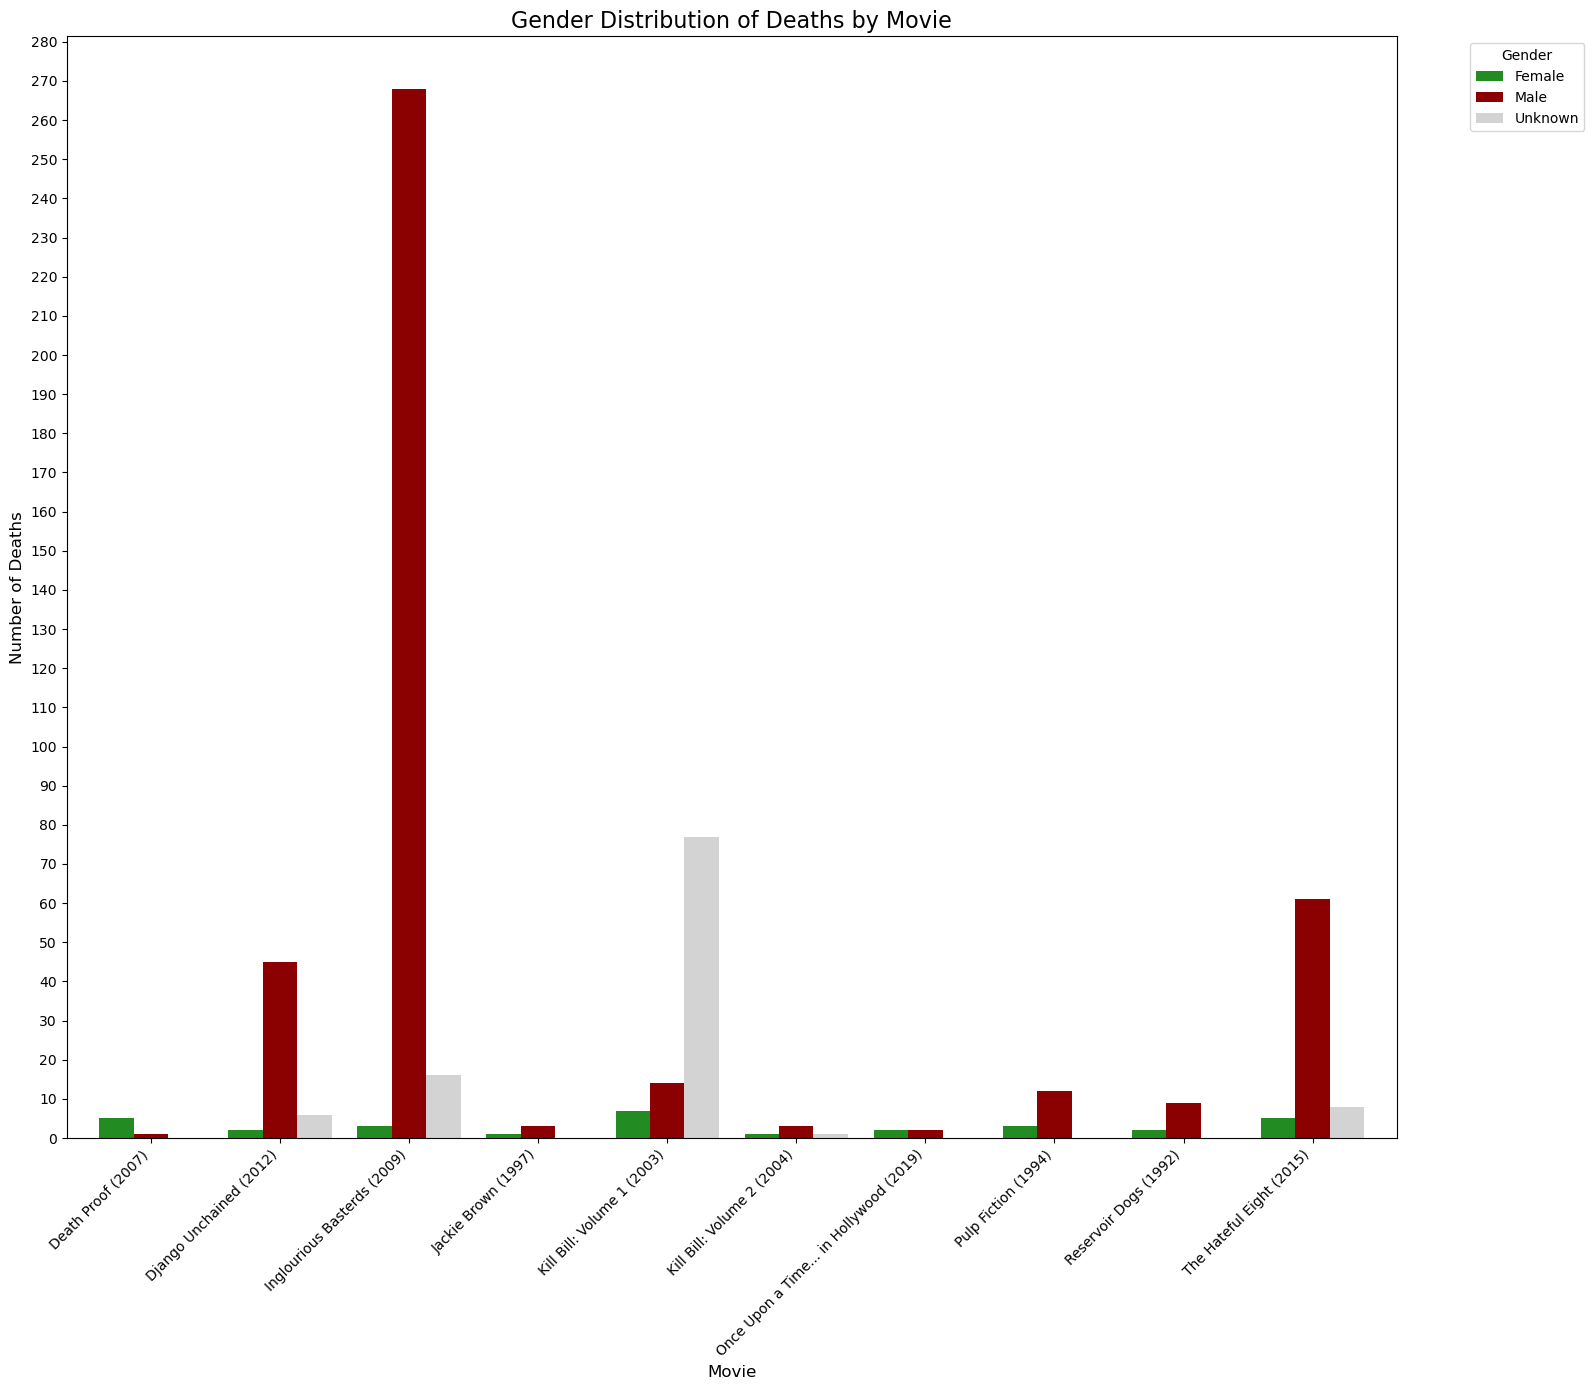

In [180]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

#loading data set from CSV file
df= pd.read_csv("all_kills.csv")
# Grouping movie and gender data
gender_count=df.groupby(['Movie', 'Gender']).size().unstack(fill_value=0)

#plottig the grouped bar chart.
fig, ax= plt.subplots(figsize=(16, 14))  
#plotting data.
gender_count.plot(kind='bar', ax=ax, width=0.8, color=["#228B22", "#8B0000", "lightgrey"])

#labelling the plot.
ax.set_title("Gender Distribution of Deaths by Movie", fontsize=16)
ax.set_xlabel("Movie", fontsize=12)
ax.set_ylabel("Number of Deaths", fontsize=12)
ax.legend(title="Gender", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')

# adjusting y axis to be ever 10 kills.
ax.yaxis.set_major_locator(MultipleLocator(10))  

#showing the plot.
plt.tight_layout()
plt.show()


/var/folders/ms/r230vchx3z5_v395lc7psj7h0000gn/T/ipykernel_36668/377340980.py:25: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.



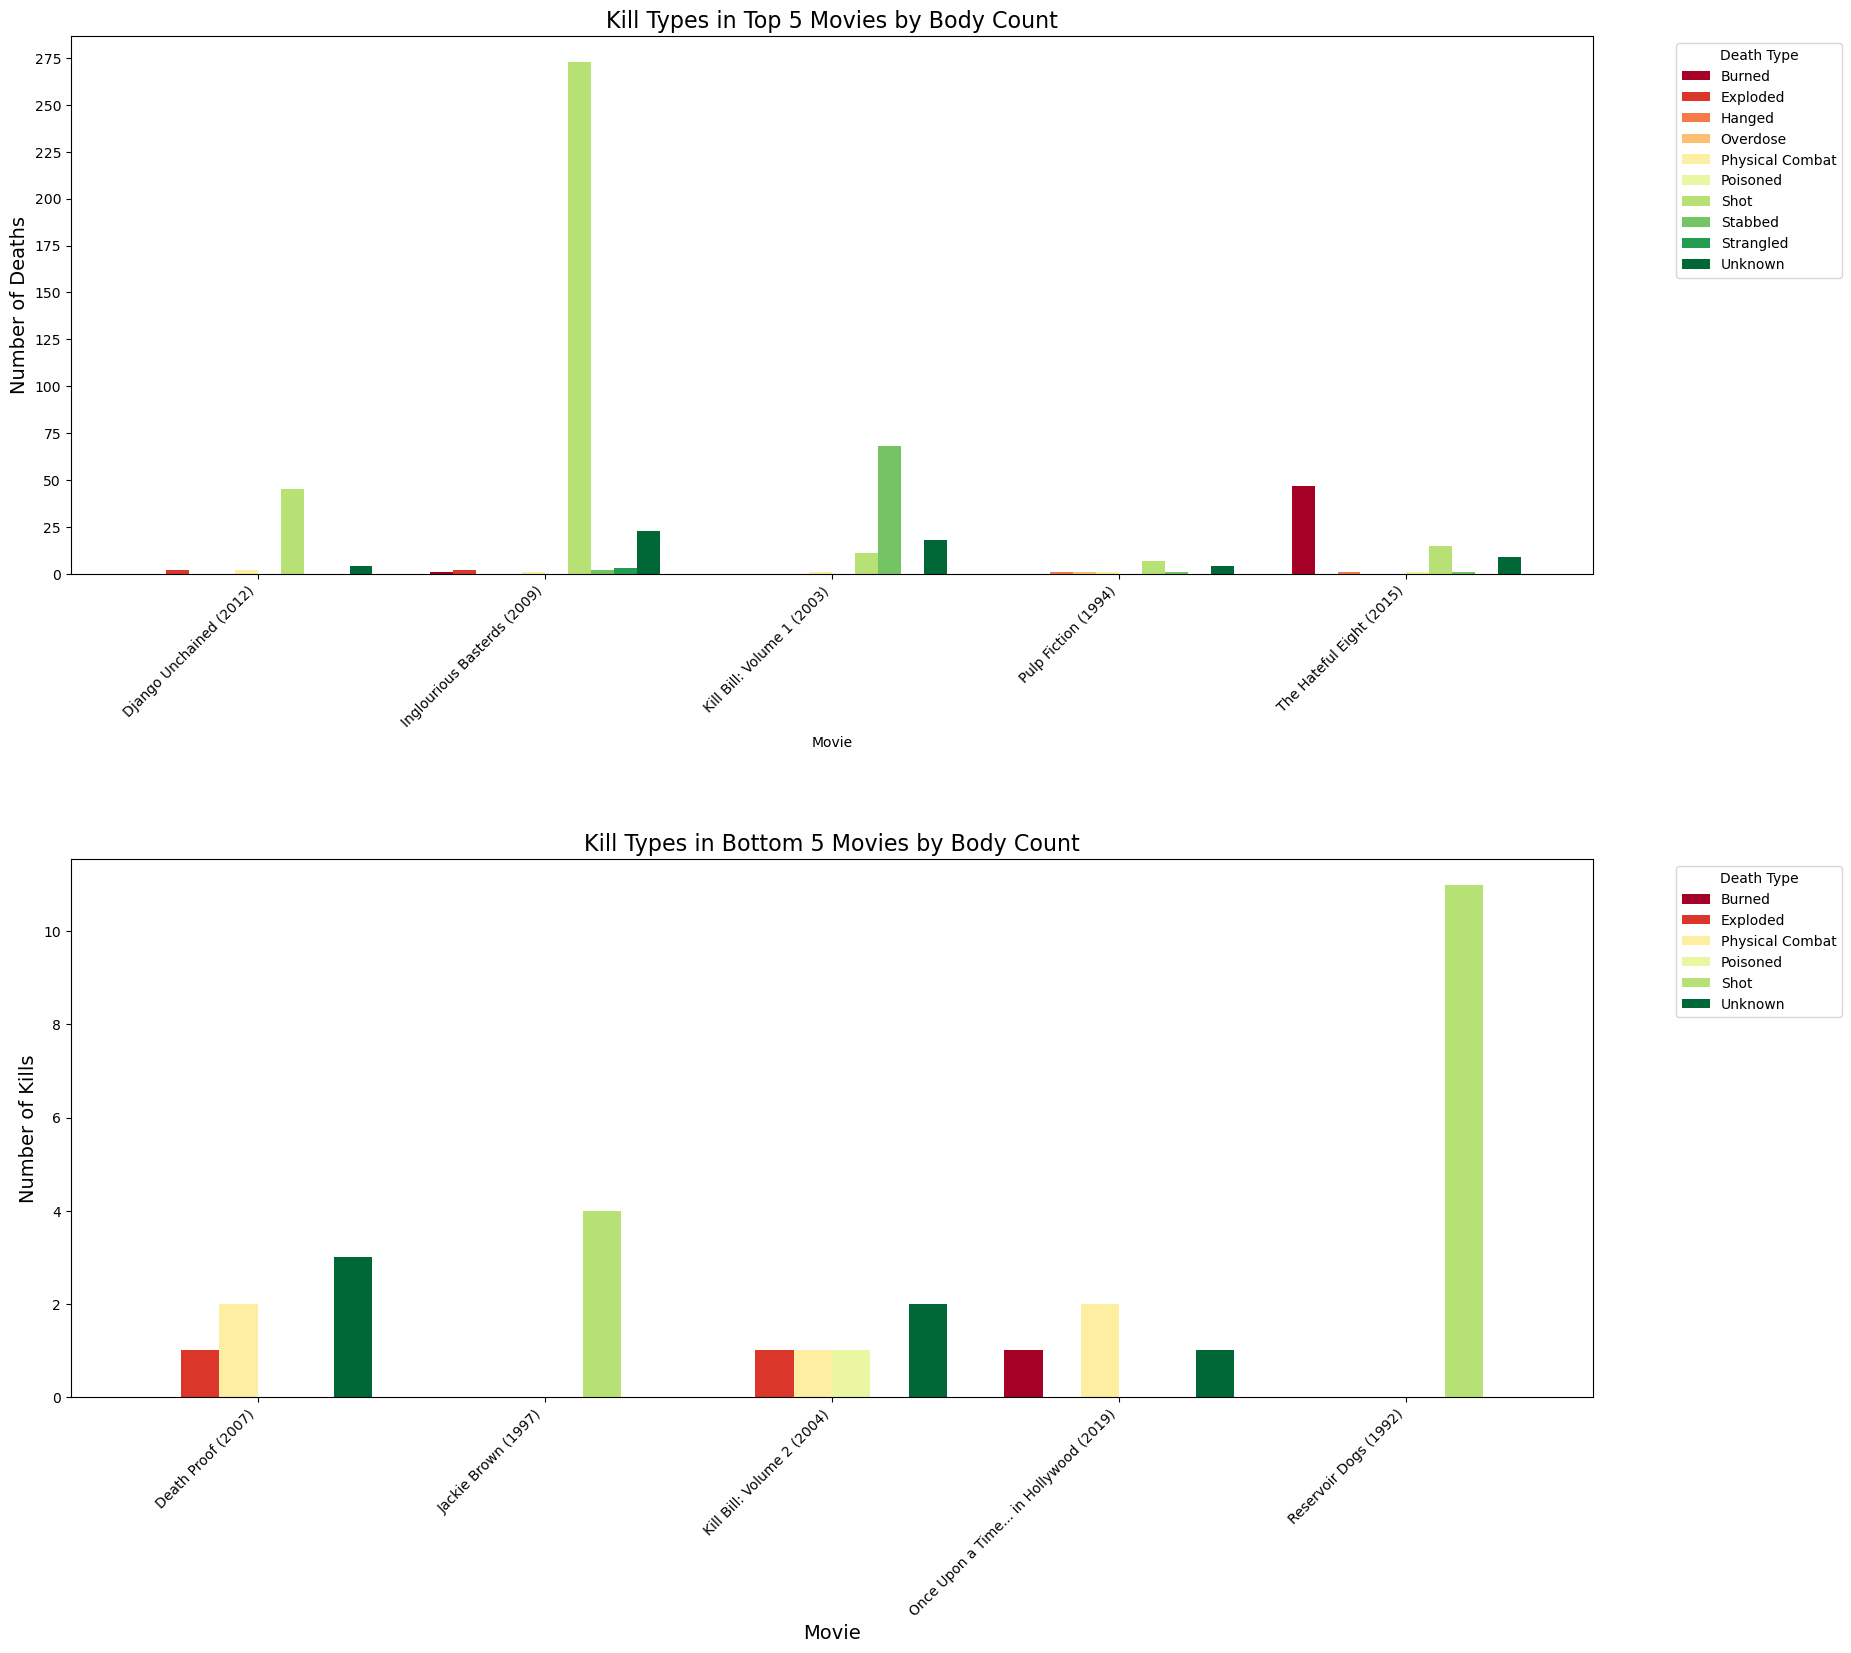

In [181]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as mcolors

#loading data from csv.
df = pd.read_csv("death_count_per_film_per_type.csv")
#grouping movie by total deaths.
total_deaths = df.groupby("Movie")["death_count"].sum()

#getting top 5 and bottom 5 to split movies as there is too much of a difference in quantities
top_movies = total_deaths.sort_values(ascending=False).head(5).index
bottom_movies = total_deaths.sort_values().head(5).index
#filtering data frames.
df_top= df[df["Movie"].isin(top_movies)]
df_bottom =df[df["Movie"].isin(bottom_movies)]

#pivot for plots.
top_pivot =df_top.pivot_table(index="Movie", columns="death_type", values="death_count", aggfunc="sum", fill_value=0)
bottom_pivot = df_bottom.pivot_table(index="Movie", columns="death_type", values="death_count", aggfunc="sum", fill_value=0)

# generating colour map.
death_types =sorted(set(df['death_type']))
cmap = cm.get_cmap("RdYlGn", len(death_types))
color_list =[mcolors.rgb2hex(cmap(i)) for i in range(len(death_types))]
color_dict= dict(zip(death_types, color_list))
#Matching the colours o the columns.
top_colors =[color_dict[dt] for dt in top_pivot.columns]
bottom_colors=[color_dict[dt] for dt in bottom_pivot.columns]

# Plotting.
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 18), dpi=100)

#top 5 movies plot.
top_pivot.plot(kind="bar", ax=ax1, color=top_colors, width=0.8)
ax1.set_title("Kill Types in Top 5 Movies by Body Count", fontsize=16)
ax1.set_ylabel("Number of Deaths", fontsize=14)
ax1.legend(title="Death Type", bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

#setting y intervals.
max_y = top_pivot.values.max()
interval = 25
ax1.set_yticks(np.arange(0, max_y + interval, interval))

#Bottom 5 movies plots
bottom_pivot.plot(kind="bar", ax=ax2, color=bottom_colors, width=0.8)
ax2.set_title("Kill Types in Bottom 5 Movies by Body Count", fontsize=16)
ax2.set_ylabel("Number of Kills", fontsize=14)
ax2.set_xlabel("Movie", fontsize=14)
ax2.legend(title="Death Type", bbox_to_anchor=(1.05, 1), loc='upper left')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')

#showing plot
plt.tight_layout(pad=6.0)
plt.show()
